# Wide & Deep Recommender Experiment

## 1. Imports and Data Loading

In [2]:
!git clone https://$GITHUB_TOKEN@github.com/Its-OP/ucu-rs-2026.git

Cloning into 'ucu-rs-2026'...
remote: Enumerating objects: 571, done.
remote: Counting objects: 100% (403/403), done.
remote: Compressing objects: 100% (276/276), done.
remote: Total 571 (delta 203), reused 272 (delta 116), pack-reused 168 (from 1)
Receiving objects: 100% (571/571), 80.02 MiB | 5.92 MiB/s, done.
Resolving deltas: 100% (262/262), done.


In [3]:
%cd ucu-rs-2026

/Users/anastasiiamazur/Projects/ucu-rs-2026/experiments/WideDeep/ucu-rs-2026


In [4]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.dataframes import train, val, test, users, movies, user_based_temporal_train, user_based_temporal_val
from src.models.wide_deep import WideAndDeepRecommender
from src.eval.offline_ranking import evaluate as evaluate_offline

warnings.filterwarnings("ignore")

In [5]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

## 2. Helpers

In [6]:
def run_offline_eval(model, train_df, eval_df, users_df, movies_df, ks=(10, 20), threshold=4.0, mode="all"):
    report = evaluate_offline(
        model=model,
        train_ratings=train_df,
        test_ratings=eval_df,
        users=users_df,
        movies=movies_df,
        ks=ks,
        threshold=threshold,
        mode=mode,
    )
    rows = []
    for k, m in report.by_k.items():
        rows.append({
            "k": k,
            "ndcg": m.ndcg,
            "precision": m.precision,
            "recall": m.recall,
            "mrr": m.mrr,
            "map": m.map,
            "n_users_evaluated": report.n_users_evaluated,
            "n_skipped": report.n_skipped,
            "skip_rate": report.skip_rate,
            "coverage_rate": report.coverage_rate,
            "avg_list_size": report.avg_list_size,
            "mode": report.mode,
        })
    return report, pd.DataFrame(rows).sort_values("k").reset_index(drop=True)


def to_long_result(df, model_name, split_name, extra=None):
    out = df.copy()
    out["model"] = model_name
    out["split"] = split_name
    if extra:
        for k, v in extra.items():
            out[k] = v
    return out


def fit_with_timing(model, train_df, users_df, movies_df, **fit_kwargs):
    t0 = time.perf_counter()
    model.fit(train_df, users=users_df, movies=movies_df, **fit_kwargs)
    train_seconds = time.perf_counter() - t0
    return train_seconds


def predict_with_timing(model, users_df, train_df, movies_df, k=20):
    t0 = time.perf_counter()
    preds = model.predict(users_df, train_df, movies_df, k=k)
    predict_seconds = time.perf_counter() - t0
    n_users = len(preds)
    time_per_user_ms = (predict_seconds / max(1, n_users)) * 1000.0
    return preds, predict_seconds, n_users, time_per_user_ms

## 3. Wide & Deep Recommender

### 3.1 Implementation Recap

1. Scoring function: $x_{ui} = x^{\text{wide}}_{ui} + x^{\text{deep}}_{ui}$, 
where:
- $x^{\text{wide}}_{ui}$ is a linear memorization component (global bias + user/item biases + demographic biases + linear genre term)
- $x^{\text{deep}}_{ui}$ is an MLP output over concatenated embeddings (user, item, demographics) and projected item-genre features

2. Loss: binary implicit-feedback objective with BCE-with-logits $\mathcal{L}_{ui} = -\left[y_{ui}\log \sigma(x_{ui}) + (1-y_{ui})\log(1-\sigma(x_{ui}))\right]$,
where $y_{ui}\in\{0,1\}$, with AdamW optimization and optional gradient clipping.

3. Positive interactions: $\text{Rating} \ge 4.0$.

4. Negative sampling: uniform sampling over items, excluding user-seen items in the training split.

5. Feature design:
- user categorical features: `Gender`, `Age`, `Occupation`
- item content feature: multi-hot `Genres` (projected in deep branch, linear in wide branch)

6. Inference: score candidate items and apply seen-item masking to exclude interactions already present in provided ratings.

7. Cold-start: for users unseen during training, fall back to global item-popularity prior from training data, still applying seen-item masking when applicable.

For full details, see: *`docs/models/wide_deep.md`*.

Paper reference: [Wide & Deep Learning for Recommender Systems (arXiv:1606.07792)](https://arxiv.org/abs/1606.07792).

### 3.2 Hyperparameter Configurations

In [ ]:
wd_grid = [
    {
        "name": "wd_e64_h128x64_neg2",
        "embedding_dim": 64,
        "hidden_dims": (128, 64),
        "n_negatives": 2,
        "dropout": 0.2,
    },
    {
        "name": "wd_e64_h256x128_neg2",
        "embedding_dim": 64,
        "hidden_dims": (256, 128),
        "n_negatives": 2,
        "dropout": 0.2,
    },
    {
        "name": "wd_e96_h192x96_neg3",
        "embedding_dim": 96,
        "hidden_dims": (192, 96),
        "n_negatives": 3,
        "dropout": 0.25,
    },
]

base_wd_params = dict(
    n_epochs=30,
    batch_size=1024,
    learning_rate=3e-4,
    weight_decay=1e-6,
    threshold=4.0,
    genre_embedding_dim=16,
    max_positive_samples_per_epoch=0,
    gradient_clip_norm=5.0,
    random_state=42,
    device="cpu",
)

### 3.3. Training and Evaluation

In [8]:
KS = (10, 20)
THRESHOLD = 4.0
MODE = "all"

wd_models = {}
wd_histories = {}
wd_val_rows = []
wd_perf_rows = []

for cfg in wd_grid:
    params = base_wd_params.copy()
    params.update({
        "embedding_dim": cfg["embedding_dim"],
        "hidden_dims": cfg["hidden_dims"],
        "n_negatives": cfg["n_negatives"],
        "dropout": cfg["dropout"],
    })

    model = WideAndDeepRecommender(**params)
    train_seconds = fit_with_timing(
        model,
        train,
        users,
        movies,
        val_ratings=val,
        eval_ks=KS,
        monitor_k=10,
        eval_mode=MODE,
        save_best_model=True,
        best_model_path=f"runs/wide_deep_{cfg['name']}_global_best.pt",
        restore_best_weights=True,
        early_stopping_patience=3,
    )

    _, pred_seconds, n_users_pred, tpu_ms = predict_with_timing(
        model,
        users,
        train,
        movies,
        k=max(KS),
    )

    wd_models[cfg["name"]] = model
    wd_histories[cfg["name"]] = list(model.loss_history_)

    _, val_df = run_offline_eval(
        model,
        train,
        val,
        users,
        movies,
        ks=KS,
        threshold=THRESHOLD,
        mode=MODE,
    )

    wd_val_rows.append(
        to_long_result(
            val_df,
            cfg["name"],
            "val",
            {
                "embedding_dim": cfg["embedding_dim"],
                "hidden_dims": str(cfg["hidden_dims"]),
                "n_negatives": cfg["n_negatives"],
                "dropout": cfg["dropout"],
            },
        )
    )

    wd_perf_rows.append(
        {
            "model": cfg["name"],
            "total_training_time_seconds": train_seconds,
            "total_prediction_time_seconds": pred_seconds,
            "n_users_predicted": n_users_pred,
            "time_per_user_ms": tpu_ms,
        }
    )

wd_val_all = pd.concat(wd_val_rows, ignore_index=True)
wd_perf_df = pd.DataFrame(wd_perf_rows)

wd_val_all.sort_values(["k", "ndcg"], ascending=[True, False])

Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852/6040 users with no relevant items in test set (threshold=4.00)
Skipped 4852

,k,ndcg,precision,recall,mrr,map,n_users_evaluated,n_skipped,skip_rate,coverage_rate,avg_list_size,mode,model,split,embedding_dim,hidden_dims,n_negatives,dropout
0,10,0.290734,0.266096,0.053618,0.448974,0.181981,1188,4852,0.803311,1.0,20.0,all,wd_e64_h128x64_neg2,val,64,"(128, 64)",2,0.20
2,10,0.288953,0.261384,0.054461,0.453558,0.175204,1188,4852,0.803311,1.0,20.0,all,wd_e64_h256x128_neg2,val,64,"(256, 128)",2,0.20
4,10,0.286388,0.262775,0.055095,0.441582,0.176183,1188,4852,0.803311,1.0,20.0,all,wd_e96_h192x96_neg3,val,96,"(192, 96)",3,0.25
1,20,0.277344,0.242214,0.085664,0.455063,0.149979,1188,4852,0.803311,1.0,20.0,all,wd_e64_h128x64_neg2,val,64,"(128, 64)",2,0.20
3,20,0.274152,0.237416,0.085375,0.457533,0.143993,1188,4852,0.803311,1.0,20.0,all,wd_e64_h256x128_neg2,val,64,"(256, 128)",2,0.20
5,20,0.271863,0.236765,0.085332,0.446382,0.143722,1188,4852,0.803311,1.0,20.0,all,wd_e96_h192x96_neg3,val,96,"(192, 96)",3,0.25


In [9]:
wd_perf_df.sort_values("total_training_time_seconds")

,model,total_training_time_seconds,total_prediction_time_seconds,n_users_predicted,time_per_user_ms
2,wd_e96_h192x96_neg3,241.511821,24.603437,6040,4.073417
1,wd_e64_h256x128_neg2,298.975834,25.303457,6040,4.189314
0,wd_e64_h128x64_neg2,310.415322,19.883847,6040,3.292028


## 3.4. Convergence Analysis

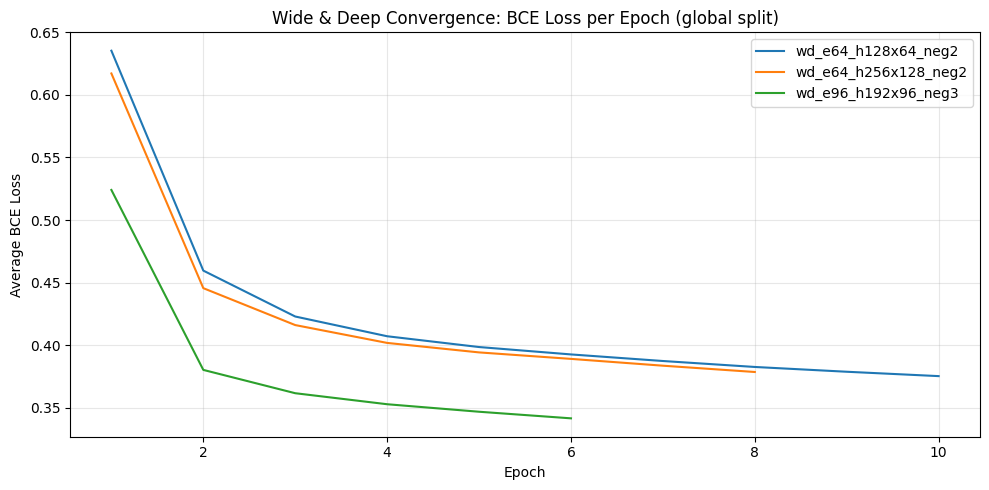

In [22]:
plt.figure(figsize=(10, 5))
for name, history in wd_histories.items():
    plt.plot(range(1, len(history) + 1), history, label=name)
plt.xlabel("Epoch")
plt.ylabel("Average BCE Loss")
plt.title("Wide & Deep Convergence: BCE Loss per Epoch (global split)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
for name, h in wd_histories.items():
    arr = np.array(h, dtype=float)
    print(name, arr, "finite=", np.isfinite(arr).all(), "min=", arr.min(), "max=", arr.max())

wd_e64_h128x64_neg2 [0.63532624 0.45960647 0.42292069 0.40714664 0.39852261 0.39261668
 0.38736281 0.38260002 0.3787755  0.37528331] finite= True min= 0.3752833070796047 max= 0.6353262364397959
wd_e64_h256x128_neg2 [0.61714735 0.44557651 0.41607431 0.40181778 0.39423488 0.38905394
 0.38361657 0.37858115] finite= True min= 0.37858114982714675 max= 0.6171473540097522
wd_e96_h192x96_neg3 [0.52405369 0.38025372 0.36162211 0.3528184  0.34681525 0.34154215] finite= True min= 0.34154214904132024 max= 0.5240536912086424


## 3.5. Final Evaluation on Test

In [12]:
best_wd_row = (
    wd_val_all[wd_val_all["k"] == 10]
    .sort_values("ndcg", ascending=False)
    .iloc[0]
)
best_wd_name = best_wd_row["model"]
best_wd_model = wd_models[best_wd_name]

best_wd_perf = wd_perf_df[wd_perf_df["model"] == best_wd_name].copy()

print("Best Wide&Deep on val (by NDCG@10):", best_wd_name)
best_wd_row

Best Wide&Deep on val (by NDCG@10): wd_e64_h128x64_neg2


k                                     10
ndcg                            0.290734
precision                       0.266096
recall                          0.053618
mrr                             0.448974
map                             0.181981
n_users_evaluated                   1188
n_skipped                           4852
skip_rate                       0.803311
coverage_rate                        1.0
avg_list_size                       20.0
mode                                 all
model                wd_e64_h128x64_neg2
split                                val
embedding_dim                         64
hidden_dims                    (128, 64)
n_negatives                            2
dropout                              0.2
Name: 0, dtype: object

In [13]:
wd_test_report, wd_test_df = run_offline_eval(
    best_wd_model,
    train,
    test,
    users,
    movies,
    ks=KS,
    threshold=THRESHOLD,
    mode=MODE,
)

wd_test_df.sort_values(["k", "ndcg"], ascending=[True, False])

Skipped 4693/6040 users with no relevant items in test set (threshold=4.00)


,k,ndcg,precision,recall,mrr,map,n_users_evaluated,n_skipped,skip_rate,coverage_rate,avg_list_size,mode
0,10,0.221120,0.198834,0.043182,0.346620,0.126795,1347,4693,0.776987,1.0,20.0,all
1,20,0.212668,0.179873,0.066479,0.353753,0.103448,1347,4693,0.776987,1.0,20.0,all


In [14]:
final_perf = best_wd_perf.copy().reset_index(drop=True)
final_perf.sort_values("model")

,model,total_training_time_seconds,total_prediction_time_seconds,n_users_predicted,time_per_user_ms
0,wd_e64_h128x64_neg2,310.415322,19.883847,6040,3.292028


## 4. Per-User Temporal Split Experiments

This section mirrors the Two-Tower split style:
- train on `user_based_temporal_train`;
- evaluate/tune on `user_based_temporal_val`.

We run the same Wide & Deep grid and report the same performance metrics.

In [15]:
USER_TRAIN = user_based_temporal_train.copy()
USER_VAL = user_based_temporal_val.copy()

print("Per-user split sizes:")
print({
    "user_based_temporal_train": len(USER_TRAIN),
    "user_based_temporal_val": len(USER_VAL),
})

Per-user split sizes:
{'user_based_temporal_train': 747909, 'user_based_temporal_val': 252300}


### 4.1. Train and Evaluation of Variants on Per-User Split

In [16]:
wd_user_models = {}
wd_user_histories = {}
wd_user_val_rows = []
wd_user_perf_rows = []

for cfg in wd_grid:
    params = base_wd_params.copy()
    params.update({
        "embedding_dim": cfg["embedding_dim"],
        "hidden_dims": cfg["hidden_dims"],
        "n_negatives": cfg["n_negatives"],
        "dropout": cfg["dropout"],
    })

    model = WideAndDeepRecommender(**params)
    train_seconds = fit_with_timing(
        model,
        USER_TRAIN,
        users,
        movies,
        val_ratings=USER_VAL,
        eval_ks=KS,
        monitor_k=10,
        eval_mode=MODE,
        save_best_model=True,
        best_model_path=f"runs/wide_deep_{cfg['name']}_user_best.pt",
        restore_best_weights=True,
        early_stopping_patience=3,
    )

    _, pred_seconds, n_users_pred, tpu_ms = predict_with_timing(
        model,
        users,
        USER_TRAIN,
        movies,
        k=max(KS),
    )

    wd_user_models[cfg["name"]] = model
    wd_user_histories[cfg["name"]] = list(model.loss_history_)

    _, user_val_df = run_offline_eval(
        model,
        USER_TRAIN,
        USER_VAL,
        users,
        movies,
        ks=KS,
        threshold=THRESHOLD,
        mode=MODE,
    )

    wd_user_val_rows.append(
        to_long_result(
            user_val_df,
            cfg["name"],
            "user_val",
            {
                "embedding_dim": cfg["embedding_dim"],
                "hidden_dims": str(cfg["hidden_dims"]),
                "n_negatives": cfg["n_negatives"],
                "dropout": cfg["dropout"],
                "split_protocol": "per_user_temporal_75_25",
            },
        )
    )

    wd_user_perf_rows.append(
        {
            "model": cfg["name"],
            "split": "per_user_temporal",
            "total_training_time_seconds": train_seconds,
            "total_prediction_time_seconds": pred_seconds,
            "n_users_predicted": n_users_pred,
            "time_per_user_ms": tpu_ms,
        }
    )

wd_user_val_all = pd.concat(wd_user_val_rows, ignore_index=True)
wd_user_perf_df = pd.DataFrame(wd_user_perf_rows)

wd_user_val_all.sort_values(["k", "ndcg"], ascending=[True, False])

Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant items in test set (threshold=4.00)
Skipped 41/6040 users with no relevant

,k,ndcg,precision,recall,mrr,map,n_users_evaluated,n_skipped,skip_rate,coverage_rate,avg_list_size,mode,model,split,embedding_dim,hidden_dims,n_negatives,dropout,split_protocol
4,10,0.127610,0.109153,0.048512,0.238891,0.059363,5999,41,0.006788,1.0,20.0,all,wd_e96_h192x96_neg3,user_val,96,"(192, 96)",3,0.25,per_user_temporal_75_25
0,10,0.121950,0.103495,0.043868,0.226714,0.056448,5999,41,0.006788,1.0,20.0,all,wd_e64_h128x64_neg2,user_val,64,"(128, 64)",2,0.20,per_user_temporal_75_25
2,10,0.120474,0.101112,0.042312,0.223049,0.055835,5999,41,0.006788,1.0,20.0,all,wd_e64_h256x128_neg2,user_val,64,"(256, 128)",2,0.20,per_user_temporal_75_25
5,20,0.129963,0.098684,0.066167,0.248285,0.048952,5999,41,0.006788,1.0,20.0,all,wd_e96_h192x96_neg3,user_val,96,"(192, 96)",3,0.25,per_user_temporal_75_25
1,20,0.123319,0.093528,0.061059,0.235949,0.046259,5999,41,0.006788,1.0,20.0,all,wd_e64_h128x64_neg2,user_val,64,"(128, 64)",2,0.20,per_user_temporal_75_25
3,20,0.121750,0.091101,0.059054,0.232651,0.045090,5999,41,0.006788,1.0,20.0,all,wd_e64_h256x128_neg2,user_val,64,"(256, 128)",2,0.20,per_user_temporal_75_25


### 4.2 Convergence Analysis

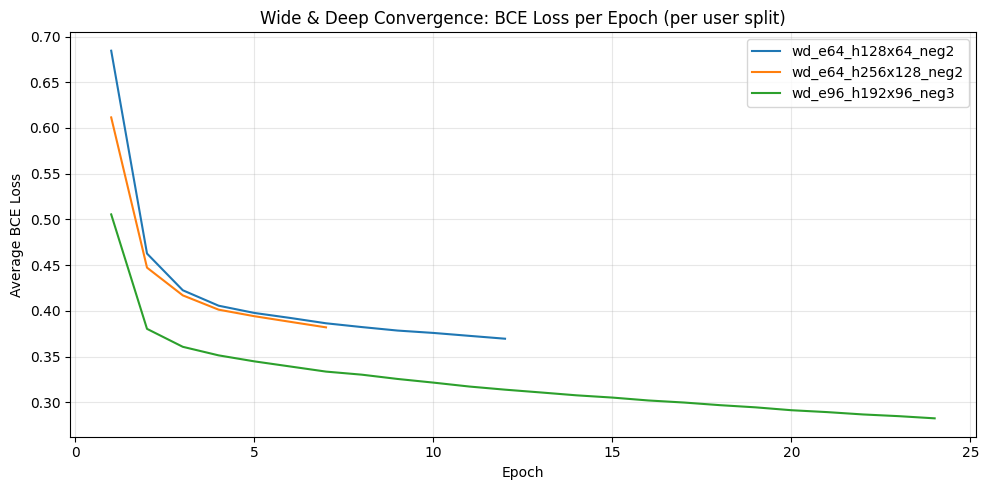

In [21]:
plt.figure(figsize=(10, 5))
for name, history in wd_user_histories.items():
    plt.plot(range(1, len(history) + 1), history, label=name)
plt.xlabel("Epoch")
plt.ylabel("Average BCE Loss")
plt.title("Wide & Deep Convergence: BCE Loss per Epoch (per user split)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3. Final Evaluation on Test

In [17]:
best_wd_user_row = (
    wd_user_val_all[wd_user_val_all["k"] == 10]
    .sort_values("ndcg", ascending=False)
    .iloc[0]
)
best_wd_user_name = best_wd_user_row["model"]
best_wd_user_model = wd_user_models[best_wd_user_name]
best_wd_user_perf = wd_user_perf_df[wd_user_perf_df["model"] == best_wd_user_name].copy()

print("Best Wide&Deep on per-user val (by NDCG@10):", best_wd_user_name)
print()
print("Metrics row:")
display(best_wd_user_row.to_frame().T)
print("Performance:")
display(best_wd_user_perf)

Best Wide&Deep on per-user val (by NDCG@10): wd_e96_h192x96_neg3

Metrics row:


,k,ndcg,precision,recall,mrr,map,n_users_evaluated,n_skipped,skip_rate,coverage_rate,avg_list_size,mode,model,split,embedding_dim,hidden_dims,n_negatives,dropout,split_protocol
4,10,0.12761,0.109153,0.048512,0.238891,0.059363,5999,41,0.006788,1.0,20.0,all,wd_e96_h192x96_neg3,user_val,96,"(192, 96)",3,0.25,per_user_temporal_75_25


Performance:


,model,split,total_training_time_seconds,total_prediction_time_seconds,n_users_predicted,time_per_user_ms
2,wd_e96_h192x96_neg3,per_user_temporal,1171.790662,25.60157,6040,4.23867


### 4.4 Global vs Per-User Protocol Comparison

In [18]:
protocol_compare = pd.DataFrame([
    {
        "protocol": "global_temporal_75_12.5_12.5",
        "best_model": best_wd_name,
        "ndcg@10": float(best_wd_row["ndcg"]),
        "recall@10": float(best_wd_row["recall"]),
        "map@10": float(best_wd_row["map"]),
        "total_training_time_seconds": float(best_wd_perf.iloc[0]["total_training_time_seconds"]),
        "total_prediction_time_seconds": float(best_wd_perf.iloc[0]["total_prediction_time_seconds"]),
        "time_per_user_ms": float(best_wd_perf.iloc[0]["time_per_user_ms"]),
    },
    {
        "protocol": "per_user_temporal_75_25",
        "best_model": best_wd_user_name,
        "ndcg@10": float(best_wd_user_row["ndcg"]),
        "recall@10": float(best_wd_user_row["recall"]),
        "map@10": float(best_wd_user_row["map"]),
        "total_training_time_seconds": float(best_wd_user_perf.iloc[0]["total_training_time_seconds"]),
        "total_prediction_time_seconds": float(best_wd_user_perf.iloc[0]["total_prediction_time_seconds"]),
        "time_per_user_ms": float(best_wd_user_perf.iloc[0]["time_per_user_ms"]),
    },
])

protocol_compare

,protocol,best_model,ndcg@10,recall@10,map@10,total_training_time_seconds,total_prediction_time_seconds,time_per_user_ms
0,global_temporal_75_12.5_12.5,wd_e64_h128x64_neg2,0.290734,0.053618,0.181981,310.415322,19.883847,3.292028
1,per_user_temporal_75_25,wd_e96_h192x96_neg3,0.127610,0.048512,0.059363,1171.790662,25.601570,4.238670
